โหลดข้อมูลสำเร็จ: 631268 แถว, 5 คอลัมน์

คอลัมน์ในข้อมูล: ['label', 'pollutant_week', 'pollution', 'pollutant', 'week']

ข้อมูลตัวอย่าง 5 แถวแรก:
        label pollutant_week  pollution pollutant  week
0  non_canyon      week1pm10  28.865471      pm10     1
1  on_viaduct      week1pm10  28.865471      pm10     1
2  on_viaduct      week1pm10  28.793261      pm10     1
3  on_viaduct      week1pm10  28.865471      pm10     1
4  on_viaduct      week1pm10  28.865471      pm10     1
สรุปข้อมูลเบื้องต้น
จำนวนสัปดาห์ทั้งหมด: 22 สัปดาห์ (สัปดาห์ที่ 1 - 22)
จำนวนพื้นที่/สถานี: 8
รายชื่อพื้นที่: ['non_canyon', 'on_viaduct', '0_hw_1', 'under_viaduct', '2_hw_4', '1_hw_2', nan, 'hw_4']...

สถิติค่า PM10:
ค่าเฉลี่ย: 49.18
ค่ามัธยฐาน: 52.66
ส่วนเบี่ยงเบนมาตรฐาน: 27.89
ค่าต่ำสุด: 3.66
ค่าสูงสุด: 154.86

ข้อมูลที่ขาดหาย:
label    3850
dtype: int64
การวิเคราะห์ ANOVA แต่ละสัปดาห์
H0: ค่าเฉลี่ย PM10 ของทุกพื้นที่เท่ากัน
H1: ค่าเฉลี่ย PM10 ของพื้นที่อย่างน้อย 1 แห่งแตกต่างจากที่อื่น
ระดับนัยสำคัญ (α) = 0.0

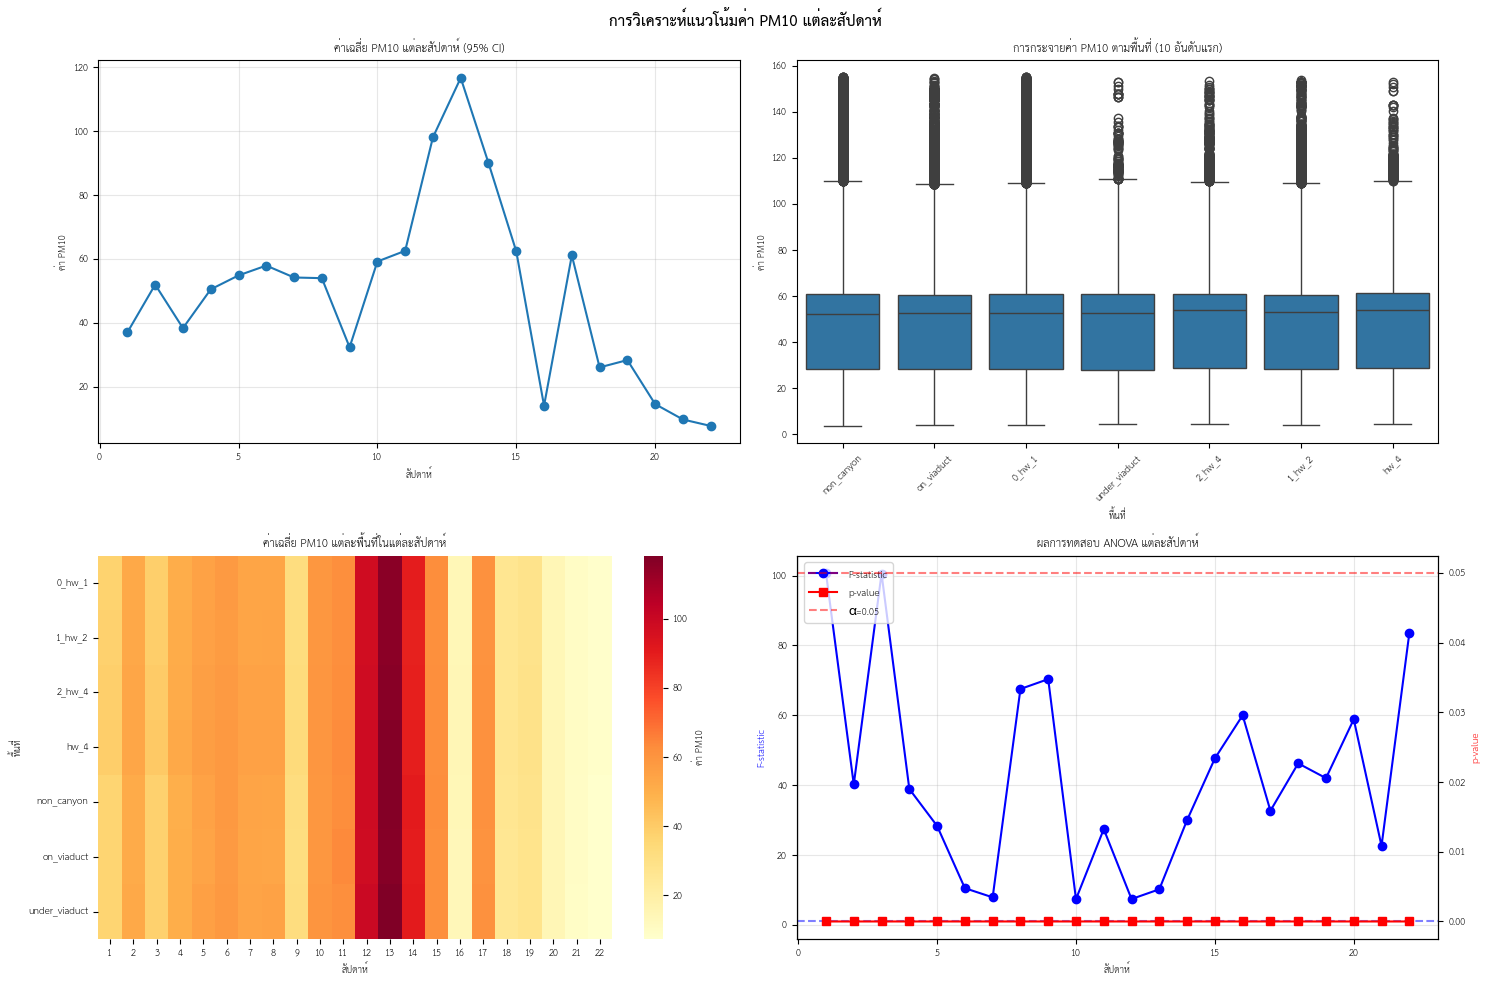


ตัวอย่างการวิเคราะห์ Post-hoc สำหรับสัปดาห์ที่ 1:
เกิดข้อผิดพลาดในการทำ Post-hoc test: '<' not supported between instances of 'float' and 'str'
บันทึกรายงานเรียบร้อยแล้ว: pm10_anova_report.txt

การวิเคราะห์เสร็จสิ้น!


In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# ตั้งค่าการแสดงผลภาษาไทย
plt.rcParams['font.family'] = ['TH Sarabun New', 'Arial Unicode MS', 'sans-serif']

class PM10_ANOVA_Analyzer:
    def __init__(self, filepath):
        """
        Initialize the analyzer with data file
        """
        self.filepath = filepath
        self.data = None
        self.anova_results = {}
        
    def load_data(self):
        """
        โหลดข้อมูลจากไฟล์ CSV
        """
        try:
            self.data = pd.read_csv(self.filepath)
            print(f"โหลดข้อมูลสำเร็จ: {len(self.data)} แถว, {len(self.data.columns)} คอลัมน์")
            print("\nคอลัมน์ในข้อมูล:", self.data.columns.tolist())
            print("\nข้อมูลตัวอย่าง 5 แถวแรก:")
            print(self.data.head())
            return True
        except Exception as e:
            print(f"เกิดข้อผิดพลาดในการโหลดข้อมูล: {e}")
            return False
    
    def explore_data(self):
        """
        สำรวจข้อมูลเบื้องต้น
        """
        if self.data is None:
            print("กรุณาโหลดข้อมูลก่อน")
            return
        
        print("=" * 60)
        print("สรุปข้อมูลเบื้องต้น")
        print("=" * 60)
        
        # จำนวนสัปดาห์
        weeks = sorted(self.data['week'].unique())
        print(f"จำนวนสัปดาห์ทั้งหมด: {len(weeks)} สัปดาห์ (สัปดาห์ที่ {min(weeks)} - {max(weeks)})")
        
        # จำนวน label (พื้นที่/สถานี)
        labels = self.data['label'].unique()
        print(f"จำนวนพื้นที่/สถานี: {len(labels)}")
        print(f"รายชื่อพื้นที่: {list(labels)[:10]}...")  # แสดง 10 แห่งแรก
        
        # สถิติพื้นฐานของค่ามลพิษ
        print(f"\nสถิติค่า PM10:")
        print(f"ค่าเฉลี่ย: {self.data['pollution'].mean():.2f}")
        print(f"ค่ามัธยฐาน: {self.data['pollution'].median():.2f}")
        print(f"ส่วนเบี่ยงเบนมาตรฐาน: {self.data['pollution'].std():.2f}")
        print(f"ค่าต่ำสุด: {self.data['pollution'].min():.2f}")
        print(f"ค่าสูงสุด: {self.data['pollution'].max():.2f}")
        
        # ตรวจสอบข้อมูลที่ขาดหาย
        missing_data = self.data.isnull().sum()
        if missing_data.sum() > 0:
            print(f"\nข้อมูลที่ขาดหาย:")
            print(missing_data[missing_data > 0])
        else:
            print("\nไม่มีข้อมูลที่ขาดหาย")
    
    def weekly_anova_analysis(self, alpha=0.05):
        """
        วิเคราะห์ ANOVA แต่ละสัปดาห์
        เปรียบเทียบค่าเฉลี่ย PM10 ระหว่างพื้นที่ต่างๆ ในแต่ละสัปดาห์
        """
        if self.data is None:
            print("กรุณาโหลดข้อมูลก่อน")
            return
        
        weeks = sorted(self.data['week'].unique())
        results = []
        
        print("=" * 80)
        print("การวิเคราะห์ ANOVA แต่ละสัปดาห์")
        print("=" * 80)
        print("H0: ค่าเฉลี่ย PM10 ของทุกพื้นที่เท่ากัน")
        print("H1: ค่าเฉลี่ย PM10 ของพื้นที่อย่างน้อย 1 แห่งแตกต่างจากที่อื่น")
        print(f"ระดับนัยสำคัญ (α) = {alpha}")
        print("=" * 80)
        
        for week in weeks:
            week_data = self.data[self.data['week'] == week]
            
            # ตรวจสอบว่ามีข้อมูลมากกว่า 1 กลุ่มหรือไม่
            unique_labels = week_data['label'].unique()
            if len(unique_labels) < 2:
                print(f"สัปดาห์ที่ {week}: ข้อมูลไม่เพียงพอ (มีเพียง {len(unique_labels)} กลุ่ม)")
                continue
            
            # จัดกลุ่มข้อมูลตาม label
            groups = []
            group_names = []
            for label in unique_labels:
                group_data = week_data[week_data['label'] == label]['pollution'].dropna()
                if len(group_data) > 0:  # ตรวจสอบว่ามีข้อมูลในกลุ่มหรือไม่
                    groups.append(group_data)
                    group_names.append(label)
            
            if len(groups) < 2:
                print(f"สัปดาห์ที่ {week}: ข้อมูลไม่เพียงพอ (มีข้อมูลเพียง {len(groups)} กลุ่ม)")
                continue
            
            # ทำ ANOVA test
            try:
                f_stat, p_value = f_oneway(*groups)
                
                # คำนวณสถิติเพิ่มเติม
                n_groups = len(groups)
                total_n = sum(len(group) for group in groups)
                group_means = [group.mean() for group in groups]
                group_stds = [group.std() for group in groups]
                overall_mean = week_data['pollution'].mean()
                
                # บันทึกผลลัพธ์
                result = {
                    'week': week,
                    'n_groups': n_groups,
                    'total_n': total_n,
                    'f_statistic': f_stat,
                    'p_value': p_value,
                    'significant': p_value < alpha,
                    'overall_mean': overall_mean,
                    'group_means': group_means,
                    'group_stds': group_stds,
                    'group_names': group_names
                }
                
                results.append(result)
                self.anova_results[week] = result
                
                # แสดงผลลัพธ์
                print(f"\nสัปดาห์ที่ {week}:")
                print(f"  จำนวนกลุ่ม: {n_groups}, จำนวนข้อมูลทั้งหมด: {total_n}")
                print(f"  F-statistic: {f_stat:.4f}")
                print(f"  p-value: {p_value:.6f}")
                print(f"  ผลการทดสอบ: {'มีความแตกต่างอย่างมีนัยสำคัญ' if p_value < alpha else 'ไม่มีความแตกต่างอย่างมีนัยสำคัญ'}")
                
                # แสดงค่าเฉลี่ยของแต่ละกลุ่ม
                print(f"  ค่าเฉลี่ยรวม: {overall_mean:.2f}")
                for i, (name, mean, std) in enumerate(zip(group_names, group_means, group_stds)):
                    print(f"    {name}: {mean:.2f} ± {std:.2f}")
                
            except Exception as e:
                print(f"สัปดาห์ที่ {week}: เกิดข้อผิดพลาด - {e}")
                continue
        
        # สรุปผลรวม
        if results:
            significant_weeks = [r for r in results if r['significant']]
            print("\n" + "=" * 80)
            print("สรุปผลการวิเคราะห์")
            print("=" * 80)
            print(f"จำนวนสัปดาห์ที่วิเคราะห์ได้: {len(results)}")
            print(f"จำนวนสัปดาห์ที่มีความแตกต่างอย่างมีนัยสำคัญ: {len(significant_weeks)}")
            print(f"สัดส่วน: {len(significant_weeks)/len(results)*100:.1f}%")
            
            if significant_weeks:
                sig_weeks = [r['week'] for r in significant_weeks]
                print(f"สัปดาห์ที่มีความแตกต่างอย่างมีนัยสำคัญ: {sig_weeks}")
        
        return results
    
    def post_hoc_analysis(self, week, alpha=0.05):
        """
        การวิเคราะห์ Post-hoc (Tukey HSD) สำหรับสัปดาห์ที่มีความแตกต่างอย่างมีนัยสำคัญ
        """
        if week not in self.anova_results:
            print(f"ไม่พบผลการวิเคราะห์ ANOVA สำหรับสัปดาห์ที่ {week}")
            return
        
        if not self.anova_results[week]['significant']:
            print(f"สัปดาห์ที่ {week} ไม่มีความแตกต่างอย่างมีนัยสำคัญ ไม่จำเป็นต้องทำ Post-hoc test")
            return
        
        week_data = self.data[self.data['week'] == week]
        
        try:
            # Tukey HSD test
            tukey = pairwise_tukeyhsd(endog=week_data['pollution'], 
                                    groups=week_data['label'], 
                                    alpha=alpha)
            
            print(f"\nผลการวิเคราะห์ Post-hoc (Tukey HSD) สำหรับสัปดาห์ที่ {week}:")
            print("=" * 80)
            print(tukey)
            
            return tukey
            
        except Exception as e:
            print(f"เกิดข้อผิดพลาดในการทำ Post-hoc test: {e}")
            return None
    
    def plot_weekly_trends(self, figsize=(15, 10)):
        """
        สร้างกราฟแสดงแนวโน้มค่า PM10 แต่ละสัปดาห์
        """
        if self.data is None:
            print("กรุณาโหลดข้อมูลก่อน")
            return
        
        # คำนวณค่าเฉลี่ยและค่าเบี่ยงเบนมาตรฐานแต่ละสัปดาห์
        weekly_stats = self.data.groupby('week')['pollution'].agg(['mean', 'std', 'count']).reset_index()
        
        # คำนวณ confidence interval
        confidence_level = 0.95
        alpha = 1 - confidence_level
        weekly_stats['se'] = weekly_stats['std'] / np.sqrt(weekly_stats['count'])
        weekly_stats['ci'] = stats.t.ppf(1 - alpha/2, weekly_stats['count'] - 1) * weekly_stats['se']
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('การวิเคราะห์แนวโน้มค่า PM10 แต่ละสัปดาห์', fontsize=16, fontweight='bold')
        
        # กราฟที่ 1: ค่าเฉลี่ยแต่ละสัปดาห์พร้อม confidence interval
        ax1 = axes[0, 0]
        ax1.errorbar(weekly_stats['week'], weekly_stats['mean'], 
                    yerr=weekly_stats['ci'], fmt='o-', capsize=3, capthick=1)
        ax1.set_title('ค่าเฉลี่ย PM10 แต่ละสัปดาห์ (95% CI)')
        ax1.set_xlabel('สัปดาห์')
        ax1.set_ylabel('ค่า PM10')
        ax1.grid(True, alpha=0.3)
        
        # กราฟที่ 2: Box plot ของค่า PM10 ตาม label (เลือกเฉพาะ label ที่มีข้อมูลมาก)
        ax2 = axes[0, 1]
        label_counts = self.data['label'].value_counts()
        top_labels = label_counts.head(10).index  # เลือก 10 label ที่มีข้อมูลมากที่สุด
        subset_data = self.data[self.data['label'].isin(top_labels)]
        
        if len(top_labels) > 0:
            sns.boxplot(data=subset_data, x='label', y='pollution', ax=ax2)
            ax2.set_title(f'การกระจายค่า PM10 ตามพื้นที่ (10 อันดับแรก)')
            ax2.set_xlabel('พื้นที่')
            ax2.set_ylabel('ค่า PM10')
            ax2.tick_params(axis='x', rotation=45)
        
        # กราฟที่ 3: Heatmap แสดงค่าเฉลี่ย PM10 ของแต่ละพื้นที่ในแต่ละสัปดาห์
        ax3 = axes[1, 0]
        pivot_data = subset_data.groupby(['week', 'label'])['pollution'].mean().unstack(fill_value=np.nan)
        
        if not pivot_data.empty:
            sns.heatmap(pivot_data.T, cmap='YlOrRd', ax=ax3, cbar_kws={'label': 'ค่า PM10'})
            ax3.set_title('ค่าเฉลี่ย PM10 แต่ละพื้นที่ในแต่ละสัปดาห์')
            ax3.set_xlabel('สัปดาห์')
            ax3.set_ylabel('พื้นที่')
        
        # กราฟที่ 4: F-statistic และ p-value จาก ANOVA แต่ละสัปดาห์
        ax4 = axes[1, 1]
        if self.anova_results:
            weeks = list(self.anova_results.keys())
            f_stats = [self.anova_results[w]['f_statistic'] for w in weeks]
            p_values = [self.anova_results[w]['p_value'] for w in weeks]
            
            # สร้าง secondary y-axis สำหรับ p-value
            ax4_2 = ax4.twinx()
            
            line1 = ax4.plot(weeks, f_stats, 'b-o', label='F-statistic')
            line2 = ax4_2.plot(weeks, p_values, 'r-s', label='p-value')
            
            ax4.axhline(y=1, color='b', linestyle='--', alpha=0.5)
            ax4_2.axhline(y=0.05, color='r', linestyle='--', alpha=0.5, label='α=0.05')
            
            ax4.set_xlabel('สัปดาห์')
            ax4.set_ylabel('F-statistic', color='b')
            ax4_2.set_ylabel('p-value', color='r')
            ax4.set_title('ผลการทดสอบ ANOVA แต่ละสัปดาห์')
            
            # รวม legend
            lines = line1 + line2 + [plt.Line2D([0], [0], color='r', linestyle='--', alpha=0.5)]
            labels = ['F-statistic', 'p-value', 'α=0.05']
            ax4.legend(lines, labels, loc='upper left')
            
            ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def generate_report(self, output_file='pm10_anova_report.txt'):
        """
        สร้างรายงานสรุปผลการวิเคราะห์
        """
        if not self.anova_results:
            print("ไม่พบผลการวิเคราะห์ กรุณาทำการวิเคราะห์ก่อน")
            return
        
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write("รายงานการวิเคราะห์ ANOVA ค่า PM10 แต่ละสัปดาห์\n")
            f.write("=" * 60 + "\n\n")
            
            # ข้อมูลเบื้องต้น
            f.write("ข้อมูลเบื้องต้น:\n")
            f.write(f"จำนวนข้อมูลทั้งหมด: {len(self.data)} แถว\n")
            f.write(f"จำนวนสัปดาห์: {len(self.data['week'].unique())} สัปดาห์\n")
            f.write(f"จำนวนพื้นที่: {len(self.data['label'].unique())} แห่ง\n")
            f.write(f"ช่วงค่า PM10: {self.data['pollution'].min():.2f} - {self.data['pollution'].max():.2f}\n")
            f.write(f"ค่าเฉลี่ย PM10 รวม: {self.data['pollution'].mean():.2f} ± {self.data['pollution'].std():.2f}\n\n")
            
            # ผลการวิเคราะห์ ANOVA
            f.write("ผลการวิเคราะห์ ANOVA:\n")
            f.write("-" * 40 + "\n")
            
            significant_weeks = []
            for week, result in sorted(self.anova_results.items()):
                f.write(f"\nสัปดาห์ที่ {week}:\n")
                f.write(f"  F-statistic: {result['f_statistic']:.4f}\n")
                f.write(f"  p-value: {result['p_value']:.6f}\n")
                f.write(f"  ผลการทดสอบ: {'มีนัยสำคัญ' if result['significant'] else 'ไม่มีนัยสำคัญ'}\n")
                f.write(f"  จำนวนกลุ่ม: {result['n_groups']}\n")
                f.write(f"  ค่าเฉลี่ยรวม: {result['overall_mean']:.2f}\n")
                
                if result['significant']:
                    significant_weeks.append(week)
            
            # สรุปผลรวม
            f.write(f"\n\nสรุปผลการวิเคราะห์:\n")
            f.write("-" * 30 + "\n")
            f.write(f"จำนวนสัปดาห์ที่วิเคราะห์: {len(self.anova_results)}\n")
            f.write(f"จำนวนสัปดาห์ที่มีความแตกต่างอย่างมีนัยสำคัญ: {len(significant_weeks)}\n")
            f.write(f"สัดส่วน: {len(significant_weeks)/len(self.anova_results)*100:.1f}%\n")
            
            if significant_weeks:
                f.write(f"สัปดาห์ที่มีความแตกต่างอย่างมีนัยสำคัญ: {significant_weeks}\n")
        
        print(f"บันทึกรายงานเรียบร้อยแล้ว: {output_file}")

# ตัวอย่างการใช้งาน
def main():
    # สร้าง analyzer object
    analyzer = PM10_ANOVA_Analyzer('pm10_byweek.csv')
    
    # โหลดข้อมูล
    if not analyzer.load_data():
        return
    
    # สำรวจข้อมูล
    analyzer.explore_data()
    
    # วิเคราะห์ ANOVA แต่ละสัปดาห์
    results = analyzer.weekly_anova_analysis(alpha=0.05)
    
    # สร้างกราฟ
    analyzer.plot_weekly_trends()
    
    # ตัวอย่างการวิเคราะห์ Post-hoc สำหรับสัปดาห์ที่มีความแตกต่าง
    significant_weeks = [r['week'] for r in results if r['significant']]
    if significant_weeks:
        print(f"\nตัวอย่างการวิเคราะห์ Post-hoc สำหรับสัปดาห์ที่ {significant_weeks[0]}:")
        analyzer.post_hoc_analysis(significant_weeks[0])
    
    # สร้างรายงาน
    analyzer.generate_report()
    
    print("\nการวิเคราะห์เสร็จสิ้น!")

if __name__ == "__main__":
    main()